# Obj D — Lucas (1980)-Inspired U.S. Appendix: M2, Inflation, and the T-Bill Rate

This appendix is where Lucas (1980) enters the project. The main cross-country analysis is motivated by Lucas (1996) and McCandless-Weber (1995); this notebook is a separate U.S. low-frequency descriptive analogue.

## Goal

Replicate the spirit of Lucas's low-frequency U.S. exercise using modern FRED data:

- M2 money growth,
- CPI inflation,
- 3-month Treasury bill rate,
- 5-year centered moving averages.

**Why M2, not M1:** Lucas (1980) used M1, but modern U.S. M1 has a major May 2020 definitional break. M2 is more stable for a 1960-2024 low-frequency appendix and closer to the broad-money concept used in the cross-country panel. This is a Lucas-inspired robustness check, not a literal variable-for-variable replication.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

RAW  = Path('../02_data/raw')
FIGS = Path('../04_current_results/figures')
TABS = Path('../04_current_results/tables')
FIGS.mkdir(parents=True, exist_ok=True)
TABS.mkdir(parents=True, exist_ok=True)

In [2]:
# ── Load monthly FRED data and annualise by yearly mean ─────────────────────
def load_annual(fname, col):
    df = pd.read_csv(RAW / fname, parse_dates=['observation_date'])
    df['year'] = df['observation_date'].dt.year
    return df.groupby('year')[col].mean().rename(col)

m2    = load_annual('fred_M2SL.csv',    'M2SL')
cpi   = load_annual('fred_CPIAUCSL.csv','CPIAUCSL')
tbill = load_annual('fred_TB3MS.csv',   'TB3MS')

us = pd.DataFrame({'m2': m2, 'cpi': cpi, 'tbill': tbill}).dropna()

# log annual changes
us['m2_growth'] = np.log(us['m2']  / us['m2'].shift(1))
us['inflation'] = np.log(us['cpi'] / us['cpi'].shift(1))
us['tbill_dec'] = us['tbill'] / 100   # percent → decimal

us = us.loc[1960:2024].dropna(subset=['m2_growth', 'inflation'])
print(f"Annual obs: {len(us)}  ({us.index.min()}–{us.index.max()})")
us[['m2_growth', 'inflation', 'tbill_dec']].describe().round(4)

Annual obs: 65  (1960–2024)


,m2_growth,inflation,tbill_dec
count,65.0000,65.0000,65.0000
mean,0.0658,0.0366,0.0438
std,0.0326,0.0259,0.0309
min,-0.0347,-0.0032,0.0003
25%,0.0508,0.0193,0.0202
50%,0.0655,0.0295,0.0435
75%,0.0795,0.0428,0.0582
max,0.1745,0.1266,0.1402


In [3]:
# ── 5-year centred moving average filter ────────────────────────────────────
MA = 5
us['m2_ma']        = us['m2_growth'].rolling(MA, center=True, min_periods=3).mean()
us['inflation_ma'] = us['inflation'].rolling(MA, center=True, min_periods=3).mean()
us['tbill_ma']     = us['tbill_dec'].rolling(MA, center=True, min_periods=3).mean()

plot_df = us.dropna(subset=['m2_ma', 'inflation_ma', 'tbill_ma'])
print(f"Filtered obs: {len(plot_df)}")

Filtered obs: 65


In [4]:
# ── OLS fits ────────────────────────────────────────────────────────────────
fit_infl  = smf.ols('inflation_ma ~ m2_ma', data=plot_df).fit()
fit_tbill = smf.ols('tbill_ma ~ m2_ma',    data=plot_df).fit()

slope_infl,  r2_infl  = fit_infl.params['m2_ma'],  fit_infl.rsquared
slope_tbill, r2_tbill = fit_tbill.params['m2_ma'], fit_tbill.rsquared

print(f"M2 → Inflation:  slope={slope_infl:.3f}, R²={r2_infl:.3f}")
print(f"M2 → T-bill:     slope={slope_tbill:.3f}, R²={r2_tbill:.3f}")

M2 → Inflation:  slope=0.474, R²=0.196
M2 → T-bill:     slope=0.421, R²=0.092


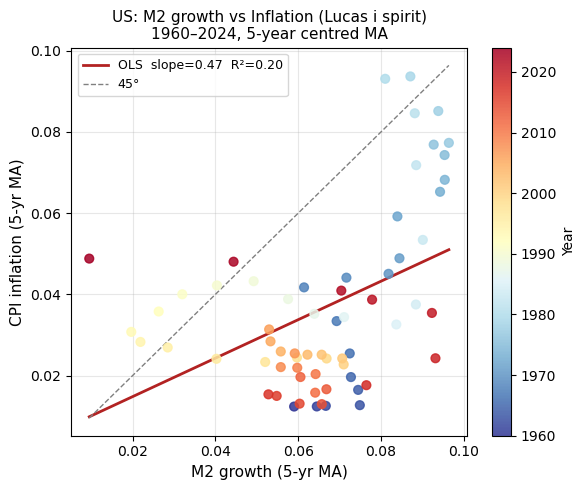

Saved lucas_us_inflation.png


In [5]:
# ── Figure 1: M2 growth vs Inflation (Lucas i spirit) ───────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(plot_df['m2_ma'], plot_df['inflation_ma'],
                c=plot_df.index, cmap='RdYlBu_r', alpha=0.85, s=40, zorder=3)
plt.colorbar(sc, ax=ax, label='Year')

x_range = np.linspace(plot_df['m2_ma'].min(), plot_df['m2_ma'].max(), 100)
ax.plot(x_range, fit_infl.params['Intercept'] + slope_infl * x_range,
        color='firebrick', linewidth=2,
        label=f'OLS  slope={slope_infl:.2f}  R²={r2_infl:.2f}')
ax.plot(x_range, x_range, color='grey', linewidth=1, linestyle='--', label='45°')

ax.set_xlabel('M2 growth (5-yr MA)', fontsize=11)
ax.set_ylabel('CPI inflation (5-yr MA)', fontsize=11)
ax.set_title('US: M2 growth vs Inflation (Lucas i spirit)\n1960–2024, 5-year centred MA', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / 'lucas_us_inflation.png', dpi=150)
plt.show()
print('Saved lucas_us_inflation.png')

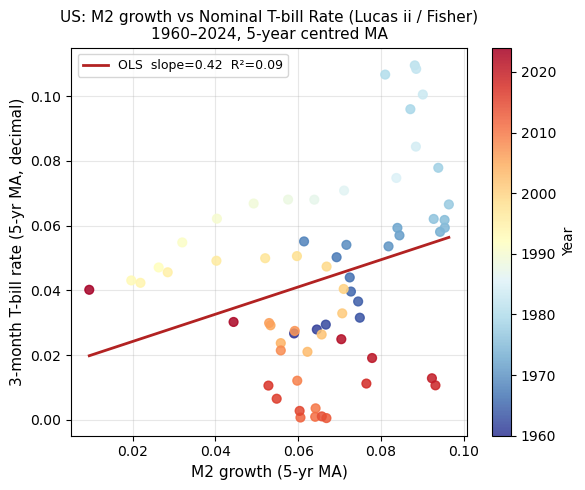

Saved lucas_us_tbill.png


In [6]:
# ── Figure 2: M2 growth vs T-bill rate (Lucas ii / Fisher) ──────────────────
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(plot_df['m2_ma'], plot_df['tbill_ma'],
                c=plot_df.index, cmap='RdYlBu_r', alpha=0.85, s=40, zorder=3)
plt.colorbar(sc, ax=ax, label='Year')

ax.plot(x_range, fit_tbill.params['Intercept'] + slope_tbill * x_range,
        color='firebrick', linewidth=2,
        label=f'OLS  slope={slope_tbill:.2f}  R²={r2_tbill:.2f}')

ax.set_xlabel('M2 growth (5-yr MA)', fontsize=11)
ax.set_ylabel('3-month T-bill rate (5-yr MA, decimal)', fontsize=11)
ax.set_title('US: M2 growth vs Nominal T-bill Rate (Lucas ii / Fisher)\n1960–2024, 5-year centred MA', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / 'lucas_us_tbill.png', dpi=150)
plt.show()
print('Saved lucas_us_tbill.png')

In [7]:
# ── Summary CSV ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'series':              'M2 (US, FRED)',
    'sample':              f"{int(plot_df.index.min())}–{int(plot_df.index.max())}",
    'n_years':             len(plot_df),
    'filter':              '5yr centred MA',
    'slope_vs_inflation':  round(slope_infl,  4),
    'r2_vs_inflation':     round(r2_infl,     4),
    'slope_vs_tbill':      round(slope_tbill, 4),
    'r2_vs_tbill':         round(r2_tbill,    4),
}])
summary.to_csv(TABS / 'lucas_us_summary.csv', index=False)
print(summary.to_string(index=False))

       series    sample  n_years         filter  slope_vs_inflation  r2_vs_inflation  slope_vs_tbill  r2_vs_tbill
M2 (US, FRED) 1960–2024       65 5yr centred MA              0.4737           0.1955           0.421       0.0924


## Interpretation

This U.S. appendix provides a Lucas (1980)-inspired single-country low-frequency check. The main cross-country analysis updates the Lucas (1996) / McCandless-Weber long-run benchmark; this appendix asks whether the same low-frequency logic appears in U.S. M2, CPI inflation, and T-bill data.

The M2-inflation slope is positive and economically meaningful. The T-bill relation points in the expected direction but is weaker and fragile under HAC inference. Treat this as descriptive support, not a separate causal claim.


In [8]:
# Newey-West HAC correction for 5-yr MA autocorrelation
# The 5-yr centred MA induces MA(4) serial correlation in the filtered series.
# OLS standard errors on the smoothed series are anti-conservative by ~sqrt(5).
# Newey-West with maxlags=4 corrects this.
import statsmodels.api as sm
import pandas as pd

print("=== US Appendix: Newey-West HAC SEs (bandwidth=4) ===")
print("Corrects for MA(4) autocorrelation induced by 5-year centred moving average.\n")

# M2 -> Inflation with NW SEs (note: column is inflation_ma, not cpi_ma)
X_nw = sm.add_constant(plot_df[['m2_ma']].dropna())
aligned = pd.concat([X_nw, plot_df['inflation_ma']], axis=1).dropna()
X_fit = aligned[['const', 'm2_ma']]
y_fit = aligned['inflation_ma']
res_nw_infl = sm.OLS(y_fit, X_fit).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(f"M2 -> Inflation (NW HAC): slope={res_nw_infl.params['m2_ma']:.4f}, "
      f"t={res_nw_infl.tvalues['m2_ma']:.3f}, p={res_nw_infl.pvalues['m2_ma']:.4f}")
print(f"  OLS slope was: {slope_infl:.4f}. HAC p-value is more conservative.")
print(f"  Effective N after 5-yr MA ~ {len(y_fit)//5} independent windows.\n")

# M2 -> T-bill with NW SEs
X_nw2 = sm.add_constant(plot_df[['m2_ma']].dropna())
aligned2 = pd.concat([X_nw2, plot_df['tbill_ma']], axis=1).dropna()
X_fit2 = aligned2[['const', 'm2_ma']]
y_fit2 = aligned2['tbill_ma']
res_nw_tbill = sm.OLS(y_fit2, X_fit2).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(f"M2 -> T-bill (NW HAC): slope={res_nw_tbill.params['m2_ma']:.4f}, "
      f"t={res_nw_tbill.tvalues['m2_ma']:.3f}, p={res_nw_tbill.pvalues['m2_ma']:.4f}")
print(f"  OLS slope was: {slope_tbill:.4f}. HAC p-value is more conservative.")


=== US Appendix: Newey-West HAC SEs (bandwidth=4) ===
Corrects for MA(4) autocorrelation induced by 5-year centred moving average.

M2 -> Inflation (NW HAC): slope=0.4737, t=1.884, p=0.0595
  OLS slope was: 0.4737. HAC p-value is more conservative.
  Effective N after 5-yr MA ~ 13 independent windows.

M2 -> T-bill (NW HAC): slope=0.4210, t=1.423, p=0.1548
  OLS slope was: 0.4210. HAC p-value is more conservative.



## US: Pre-QE vs Post-QE — Same Scatter, Two Distinct Regimes

The US M2–inflation scatter (5-yr centred MA) split at the GFC (2008).
Pre-2008: the low-frequency quantity theory link is visible (slope ~0.5–0.6).
Post-2008: the QE decade compresses the slope toward zero.
COVID-era years (2020–2024) labelled individually — they pull the post-GFC slope back up,
but not enough to match the pre-2008 relationship.


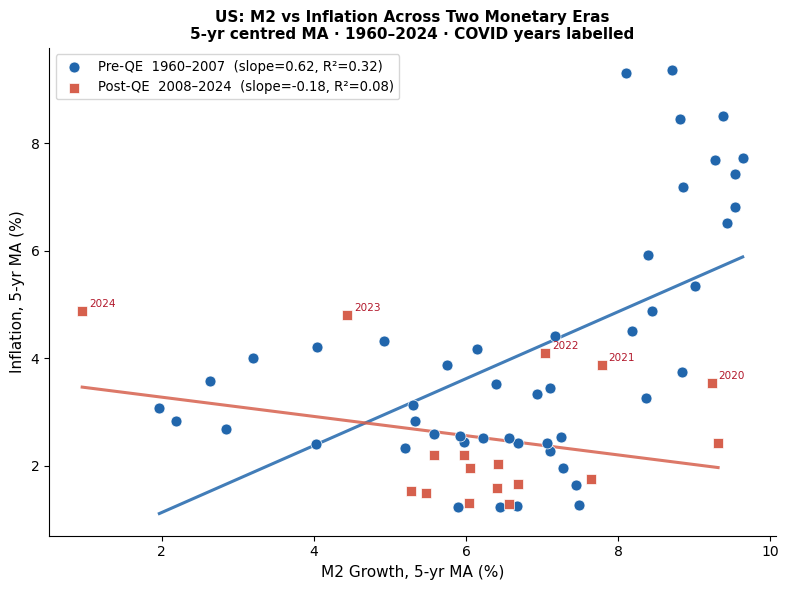

Saved → us_m2_inflation_two_eras.png


In [9]:

# ── US M2 vs inflation: pre- vs post-QE scatter, same 5-yr MA data ───────────
# plot_df and FIGS are already defined in the cells above
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

pre  = plot_df[plot_df.index <= 2007]
post = plot_df[plot_df.index >= 2008]

fig, ax = plt.subplots(figsize=(8, 6))

def add_era(df, color, marker, era_label):
    x = df["m2_ma"] * 100
    y = df["inflation_ma"] * 100
    sl, ic, r, _, _ = stats.linregress(x.values, y.values)
    ax.scatter(x, y, color=color, marker=marker, s=62, zorder=3,
               edgecolors="white", lw=0.5,
               label=f"{era_label}  (slope={sl:.2f}, R²={r**2:.2f})")
    xfit = np.linspace(float(x.min()), float(x.max()), 100)
    ax.plot(xfit, ic + sl * xfit, color=color, lw=2.2, alpha=0.85)

add_era(pre,  "#2166ac", "o", "Pre-QE  1960–2007")
add_era(post, "#d6604d", "s", "Post-QE  2008–2024")

for yr, row in plot_df[plot_df.index >= 2020].iterrows():
    ax.annotate(str(yr), (row["m2_ma"] * 100, row["inflation_ma"] * 100),
                fontsize=7.5, color="#b2182b",
                textcoords="offset points", xytext=(5, 3))

ax.set_xlabel("M2 Growth, 5-yr MA (%)", fontsize=11)
ax.set_ylabel("Inflation, 5-yr MA (%)", fontsize=11)
ax.set_title(
    "US: M2 vs Inflation Across Two Monetary Eras\n"
    "5-yr centred MA · 1960–2024 · COVID years labelled",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(FIGS / "us_m2_inflation_two_eras.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → us_m2_inflation_two_eras.png")
